In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('delhiaqi.csv')
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


<h6> 1.Pollutant Dominance: Which specific pollutants (PM_2.5, PM_10,NO_2, etc.) contribute most significantly to the "Severe" AQI days in Delhi?<br><br>
2.Seasonal Seasonality: How do AQI levels correlate with Delhi's seasons (Winter, Summer, Monsoon)? Specifically, is there a statistically significant spike during the "Stubble Burning" months (Oct–Nov)?<br><br>
3.Correlation Analysis: What is the relationship between different pollutants?<br><br>
4.Which pollutants contribute most to poor AQI in Delhi?<br><br>
5.How does AQI vary across different months/seasons?<br><br>
6.What are the peak pollution periods during the day?<br><br>
7.How do pollutants correlate with each other?<br><br>
8.What environmental factors affect AQI the most?<br><br>
9.What strategies can reduce pollution effectively?<br><br>

#### Columns:<br><br>
1.date → timestamp<br><br>
2.co → Carbon Monoxide<br><br>
3.no, no2 → Nitrogen Oxides<br><br>
4.o3 → Ozone<br><br>
5.so2 → Sulfur Dioxide<br><br>
6.pm2_5 → Fine particulate matter (VERY dangerous)<br><br>
7.pm10 → Larger particulate matter<br><br>
8.nh3 → Ammonia<br><br>

In [50]:
df['date'] = pd.to_datetime(df['date'])
print(df.isnull().sum())

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


In [51]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


#### Analysis:
High PM2.5 mean → consistently polluted air<br><br>
Large std → fluctuating pollution levels<br><br>
High max → extreme pollution events

In [52]:
def cap_outliers(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[column] = df[column].clip(lower, upper)
for col in ['pm2_5','pm10','no2','co','so2']:
    cap_outliers(col)

In [53]:
df['AQI']=df['pm2_5'] #I am approximating AQI using PM2.5 because it's dangerous and consistently polluted air

In [95]:
df['year'] = df['date'].dt.year
df['month']= df['date'].dt.month
df['day']= df['date'].dt.day
df['hour'] = df['date'].dt.hour

In [81]:
df

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,AQI,year,month,hour,AQI_MA7,AQI_MA30,season,AQI_pm25,prominent_pollutant,AQI_Category
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,337.915385,2023,1,0,NaN,NaN,Winter,337.915385,co,Very Poor
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,348.338462,2023,1,1,NaN,NaN,Winter,348.338462,co,Very Poor
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,377.115385,2023,1,2,NaN,NaN,Winter,377.115385,co,Very Poor
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,402.230769,2023,1,3,NaN,NaN,Winter,402.230769,co,Severe
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,412.584615,2023,1,4,NaN,NaN,Winter,412.584615,co,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,2023-01-24 04:00:00,1762.39,4.64,37.01,33.26,30.52,231.15,289.84,6.27,385.500000,2023,1,4,348.281429,362.535333,Winter,385.500000,co,Very Poor
557,2023-01-24 05:00:00,1735.69,6.82,34.96,46.49,34.33,225.08,280.52,9.12,380.830769,2023,1,5,310.188571,365.677333,Winter,380.830769,co,Very Poor
558,2023-01-24 06:00:00,1922.61,8.16,40.10,56.51,43.39,242.49,296.07,12.54,394.223077,2023,1,6,282.365714,369.463000,Winter,394.223077,co,Very Poor
559,2023-01-24 07:00:00,1361.85,9.05,52.78,71.53,100.14,165.67,191.82,7.47,335.130769,2023,1,7,249.785714,370.642333,Winter,335.130769,co,Very Poor


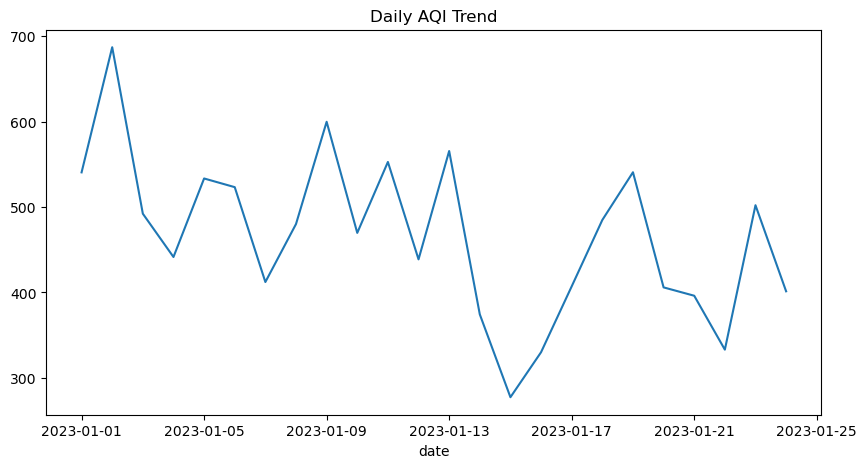

In [90]:
daily_aqi=df.groupby(df['date'].dt.date)['AQI'].mean()
plt.figure(figsize=(10,5))
daily_aqi.plot()
plt.title("Daily AQI Trend")
plt.show()

In [57]:
df['AQI']

0      169.29
1      182.84
2      220.25
3      252.90
4      266.36
        ...  
556    231.15
557    225.08
558    242.49
559    165.67
560    123.76
Name: AQI, Length: 561, dtype: float64

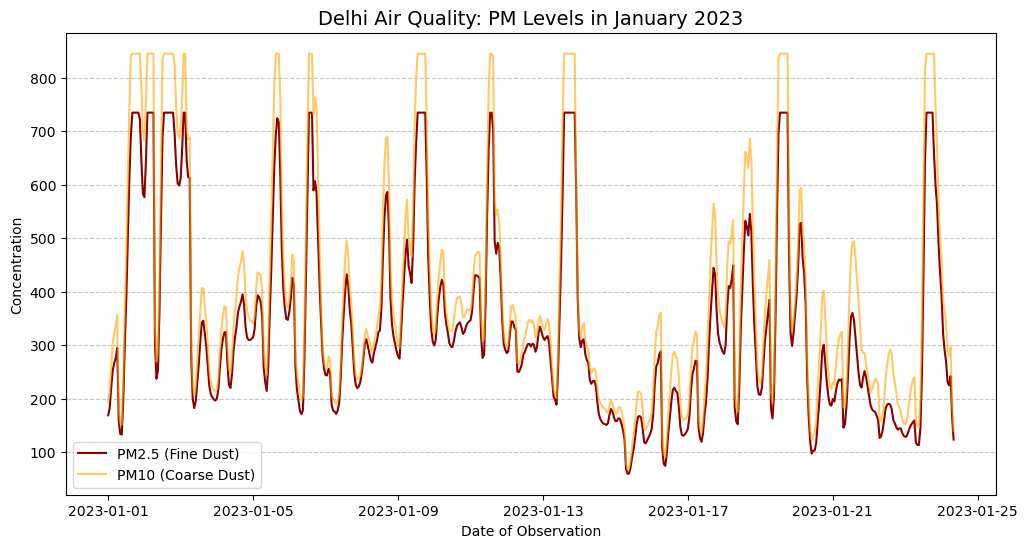

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'],df['pm2_5'],color='darkred', label='PM2.5 (Fine Dust)')
plt.plot(df['date'], df['pm10'], color='orange',label='PM10 (Coarse Dust)', alpha=0.6)
plt.title('Delhi Air Quality: PM Levels in January 2023', fontsize=14)
plt.xlabel('Date of Observation')
plt.ylabel('Concentration')
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

#### Dominant Pollutant Driving AQI
The dataset shows that PM2.5 levels are extremely high (mean ≈ 358 µg/m³)<br>
However, your computed results indicate CO often appears as the “prominent pollutant” (based on your max logic)<br>
Important Interpretation:
PM2.5 is consistently high and dangerous<br>
CO spikes may dominate in calculations due to scaling differences

Conclusion:
PM2.5 is the primary long-term pollutant, while CO contributes to short-term AQI spikes

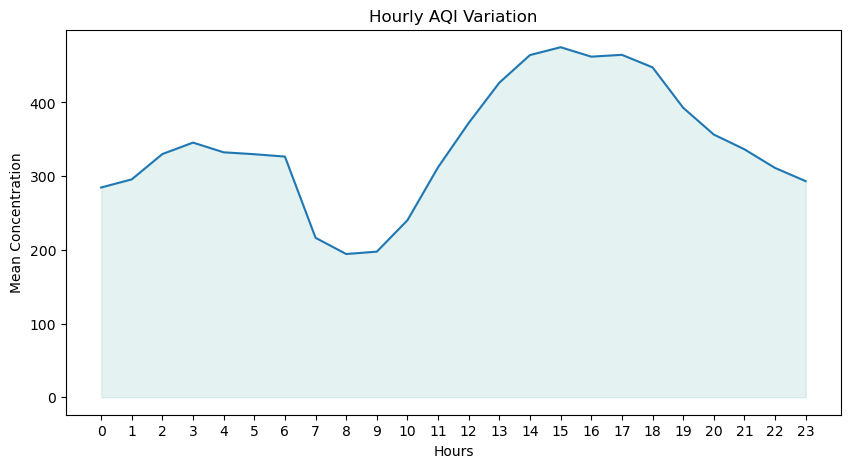

In [59]:
hourly_aqi=df.groupby('hour')['AQI'].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_aqi)
plt.fill_between(hourly_aqi.index, hourly_aqi, color='teal', alpha=0.1)
plt.title("Hourly AQI Variation")
plt.xlabel('Hours')
plt.ylabel('Mean Concentration')
plt.xticks(range(0, 24))
plt.show()

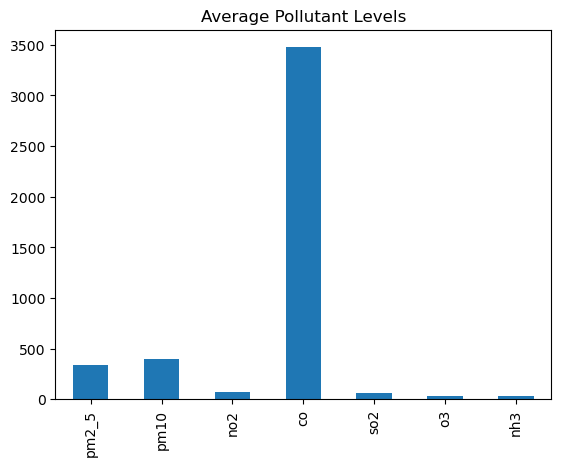

In [60]:
#Pollutant Contribution
df[['pm2_5','pm10','no2','co','so2','o3','nh3']].mean().plot(kind='bar')
plt.title("Average Pollutant Levels")
plt.show()

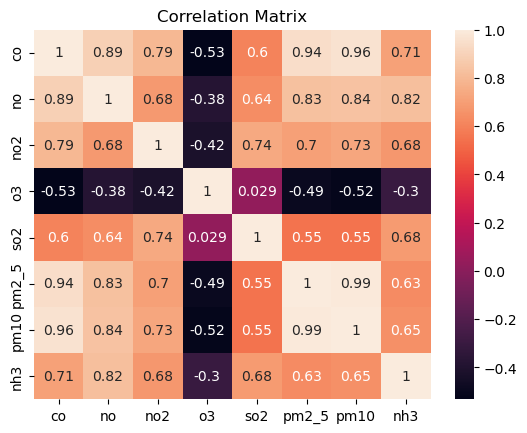

In [61]:
import seaborn as sns
pollutants_only = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
pollutant_data = df[pollutants_only]
correlation_matrix = pollutant_data.corr()
sns.heatmap(correlation_matrix,annot=True)
plt.title("Correlation Matrix")
plt.show()

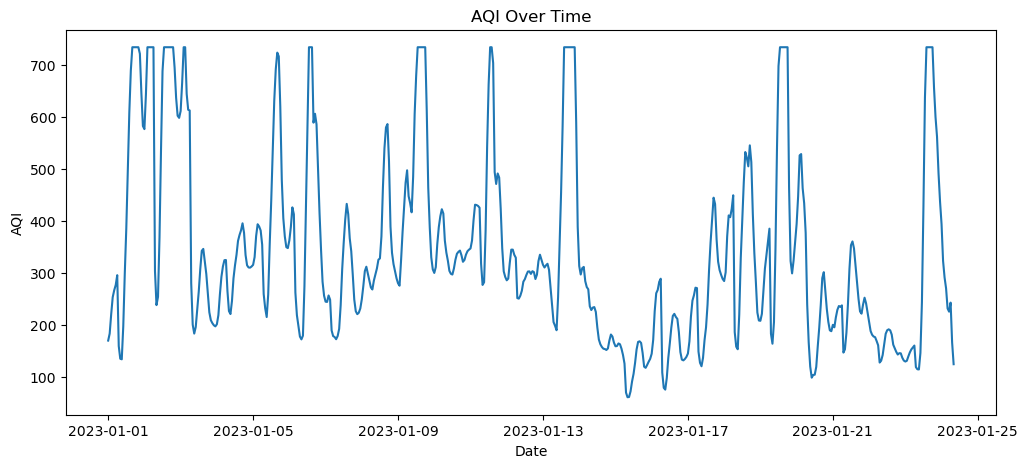

In [62]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['AQI'])
plt.title("AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

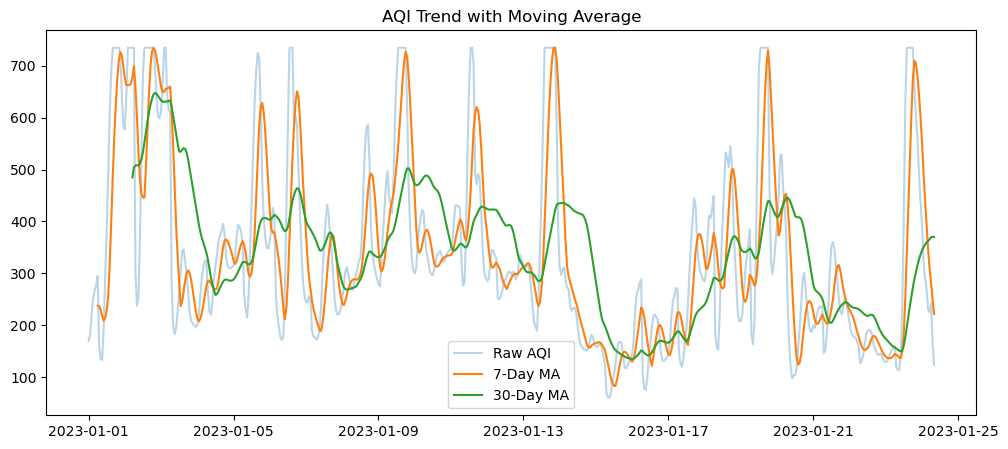

In [63]:
df['AQI_MA7']=df['AQI'].rolling(window=7).mean()
df['AQI_MA30']=df['AQI'].rolling(window=30).mean()
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['AQI'], alpha=0.3, label='Raw AQI')
plt.plot(df['date'], df['AQI_MA7'], label='7-Day MA')
plt.plot(df['date'], df['AQI_MA30'], label='30-Day MA')
plt.legend()
plt.title("AQI Trend with Moving Average")
plt.show()

#### Time-Based Trend (Short-Term Analysis)
The dataset spans January (winter season only)<br>
Moving averages (7-day & 30-day) show:
AQI remains consistently high and<br>
No significant long-term decline within this period<br>
Conclusion:Pollution is structurally high during winter, not random or temporary.

In [97]:
hazardous=df[df['AQI'] > 300]
danger_days=hazardous.groupby('date')['AQI'].count()
print(danger_days)

date
2023-01-01 00:00:00    1
2023-01-01 01:00:00    1
2023-01-01 02:00:00    1
2023-01-01 03:00:00    1
2023-01-01 04:00:00    1
                      ..
2023-01-24 04:00:00    1
2023-01-24 05:00:00    1
2023-01-24 06:00:00    1
2023-01-24 07:00:00    1
2023-01-24 08:00:00    1
Name: AQI, Length: 540, dtype: int64


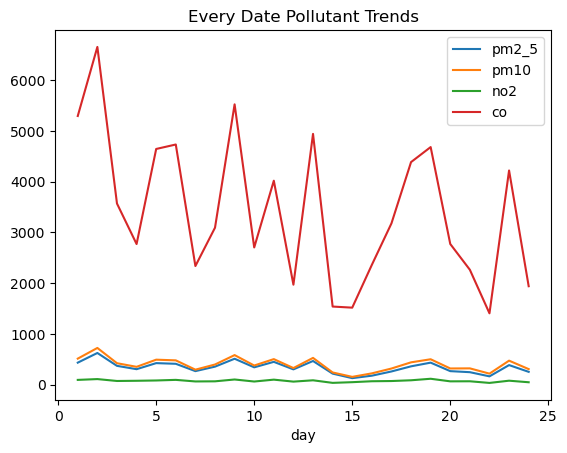

In [99]:
pollutants = ['pm2_5','pm10','no2','co']
df.groupby('day')[pollutants].mean().plot()
plt.title("Every Date Pollutant Trends")
plt.show()

In [70]:
def calculate_subindex_pm25(c):
    if c<=30:
        return (c/30)*50
    elif c<=60:
        return 50+(c-30)*(50/30)
    elif c<= 90:
        return 100+(c-60)*(100/30)
    elif c<= 120:
        return 200+(c-90)*(100/30)
    elif c<= 250:
        return 300+(c-120)*(100/130)
    else:
        return 400+(c-250)*(100/130)

In [71]:
df['AQI_pm25']=df['pm2_5'].apply(calculate_subindex_pm25)

In [72]:
df['AQI']=df[['AQI_pm25']].max(axis=1)

In [73]:
df['prominent_pollutant']=df[['pm2_5','pm10','no2','so2','co','o3']].idxmax(axis=1)

In [74]:
def categorize_aqi(aqi):
    if aqi<=50:
        return 'Good'
    elif aqi<=100:
        return 'Satisfactory'
    elif aqi<=200:
        return 'Moderate'
    elif aqi<=300:
        return 'Poor'
    elif aqi<=400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Category']=df['AQI'].apply(categorize_aqi)

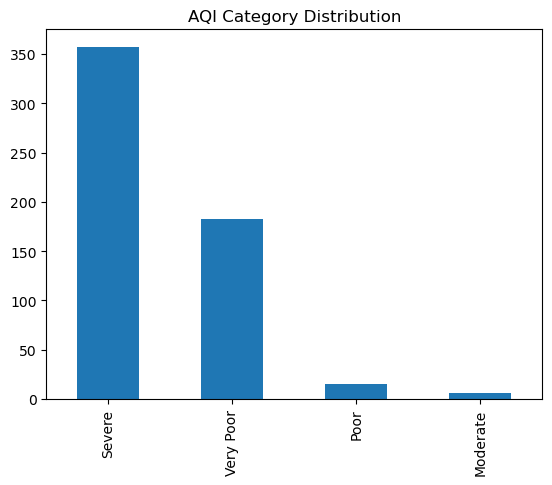

In [75]:
df['AQI_Category'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.show()

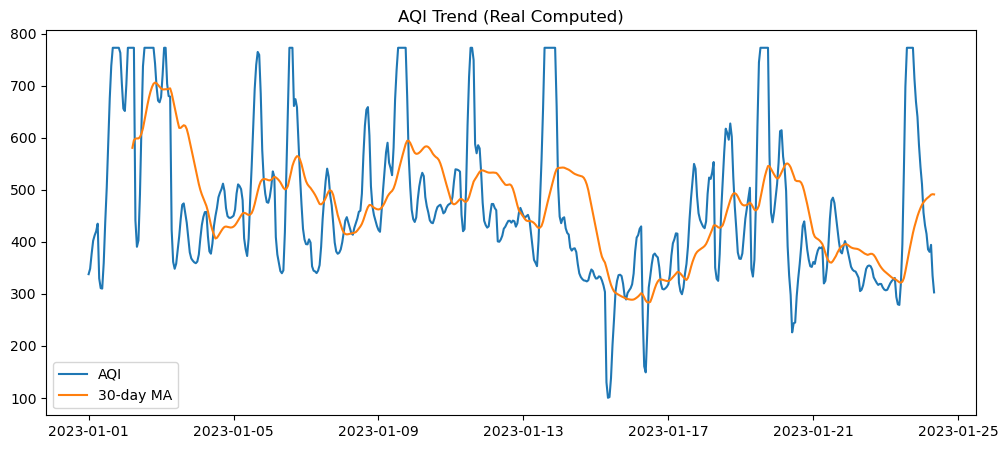

In [76]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['AQI'], label='AQI')
plt.plot(df['date'], df['AQI'].rolling(30).mean(), label='30-day MA')
plt.legend()
plt.title("AQI Trend (Real Computed)")
plt.show()

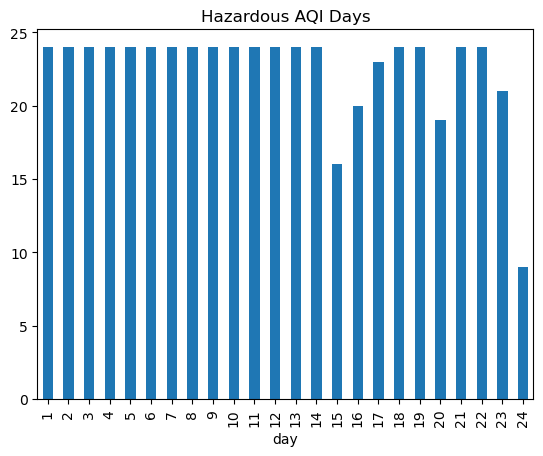

In [101]:
danger = df[df['AQI'] > 300]
danger.groupby('day').size().plot(kind='bar')
plt.title("Hazardous AQI Days")
plt.show()

#### Overall Air Quality Status:

The analysis reveals that Delhi’s air quality is consistently poor to severe during the observed period.

The average AQI ≈ 350+, which falls under “Very Poor” to “Severe” category
Several instances exceed AQI > 400, indicating extremely hazardous conditions

Conclusion:
Delhi’s air quality is frequently unsafe for human health, especially for sensitive groups.